<a href="https://colab.research.google.com/github/mastartseva/mentor_task_1/blob/main/task_1_2_mentor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset from kaggle - "Netflix Movies and TV Shows - хорош для моделей"

1. Download from kaggle

In [ ]:
!kaggle datasets download shivamb/netflix-shows

Dataset URL: https://www.kaggle.com/datasets/shivamb/netflix-shows
License(s): CC0-1.0
100% 1.34M/1.34M [00:00<00:00, 58.0MB/s]



In [ ]:
!unzip netflix-shows.zip

Archive:  netflix-shows.zip
  inflating: netflix_titles.csv      


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("netflix_titles.csv")
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


2. Basic analysis using sweetviz

In [ ]:
!pip install sweetviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 61.3 MB/s eta 0:00:00


In [ ]:
import sweetviz as sv

                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.



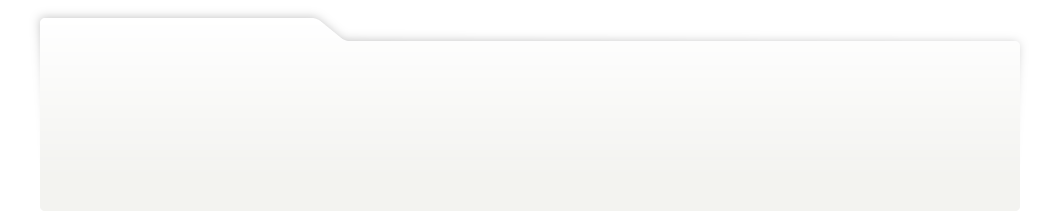
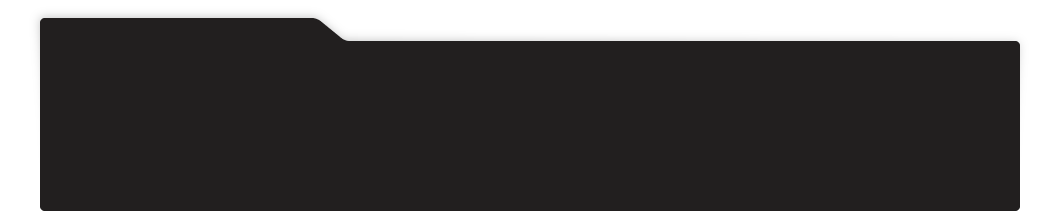
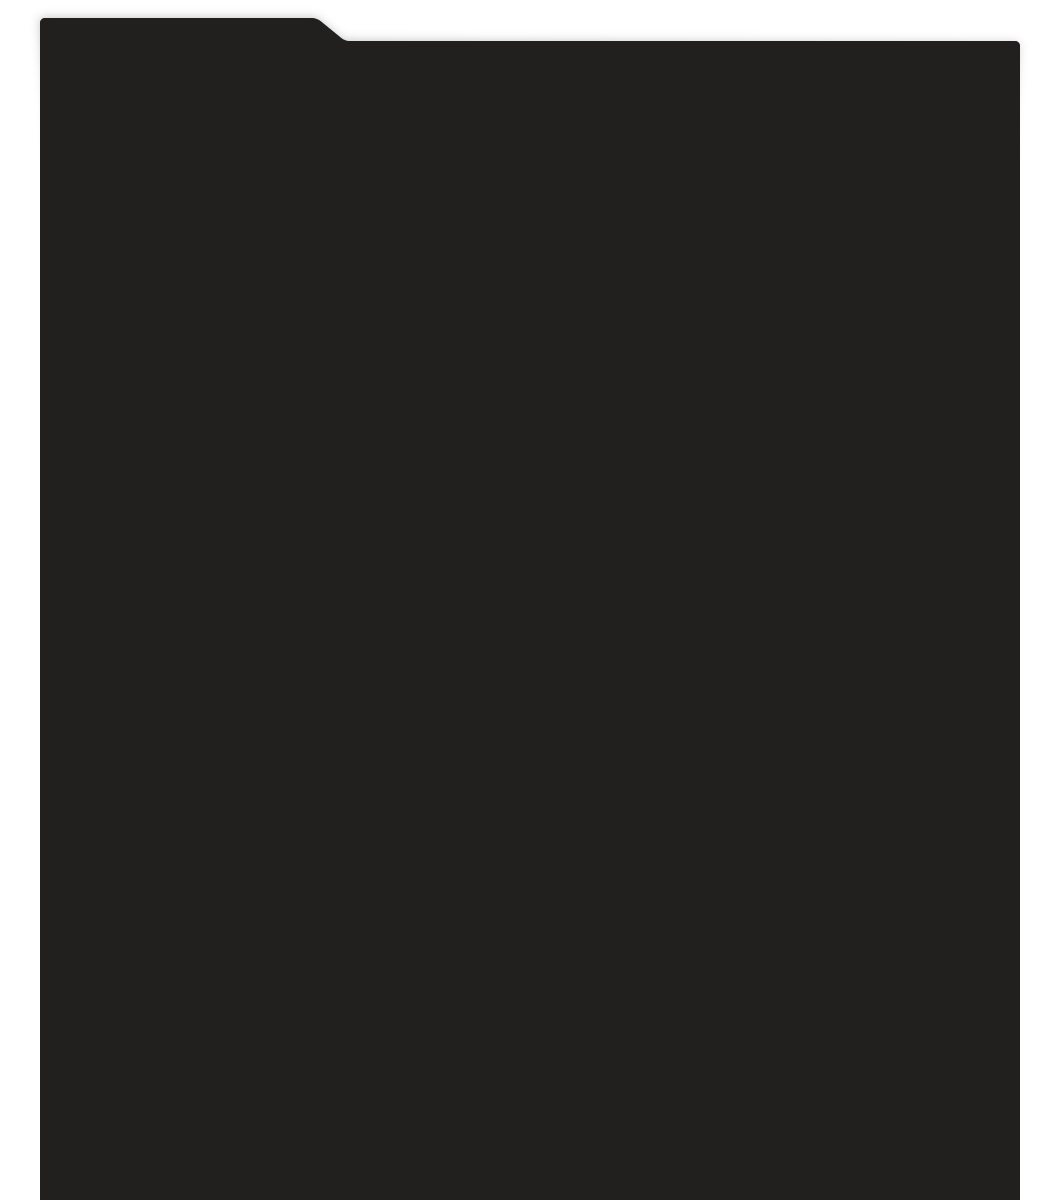
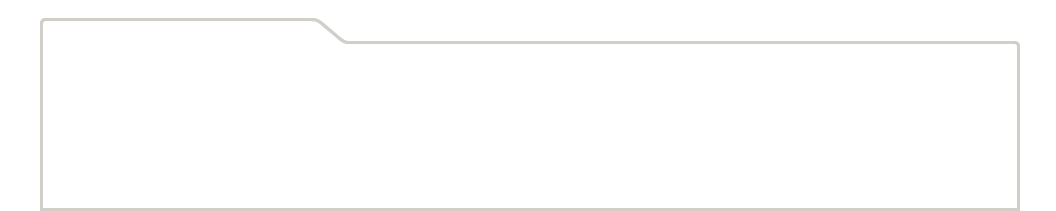
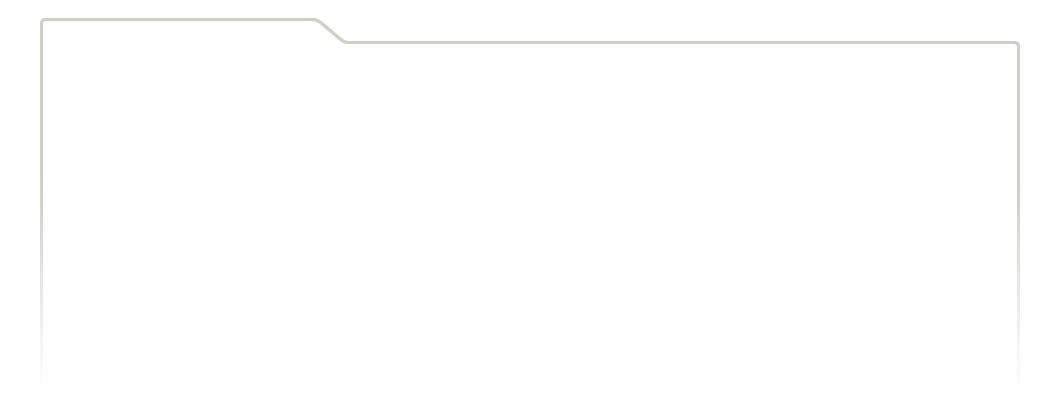
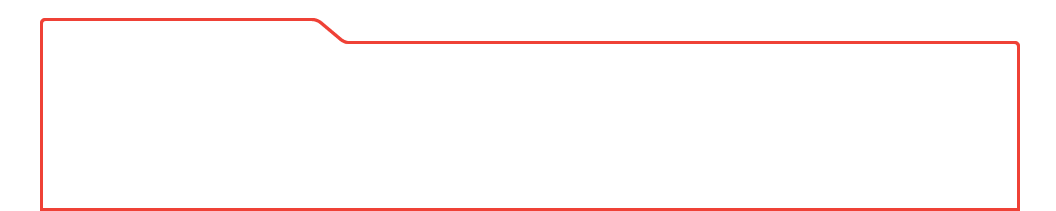
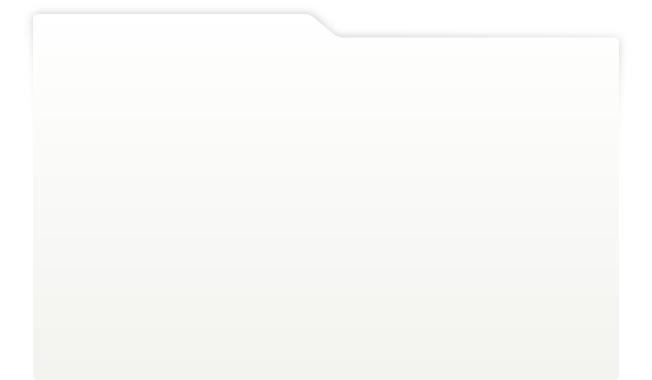
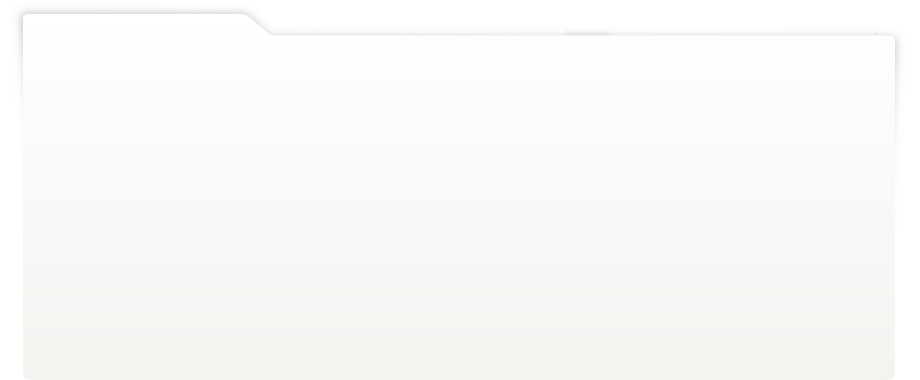
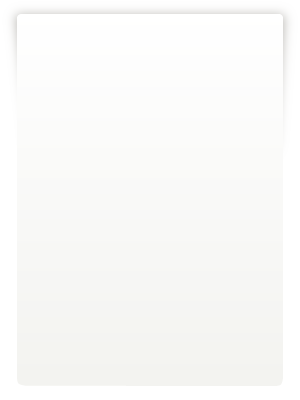
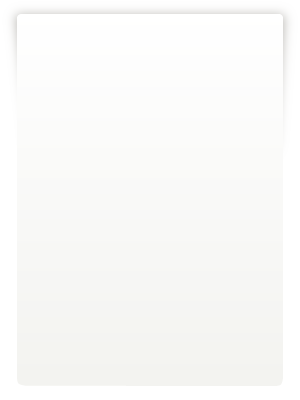
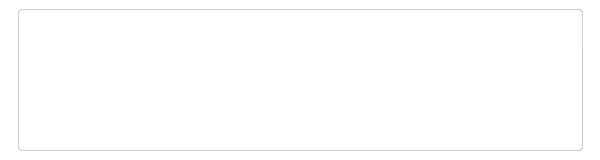
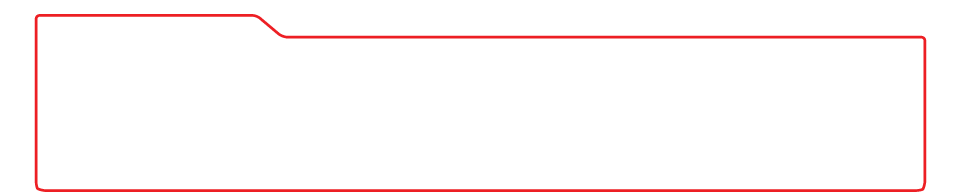
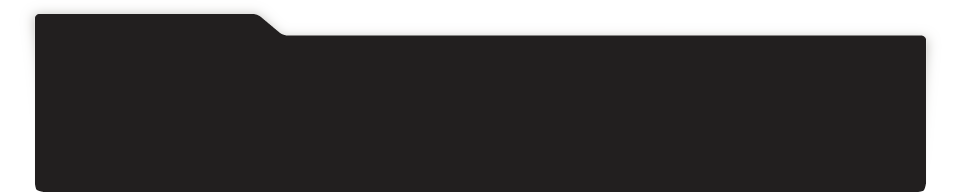
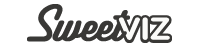
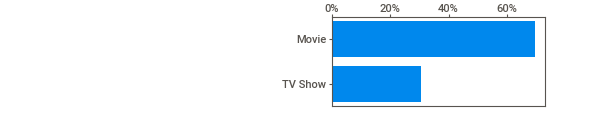
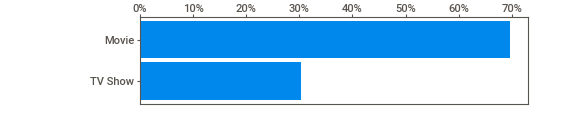
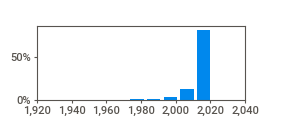
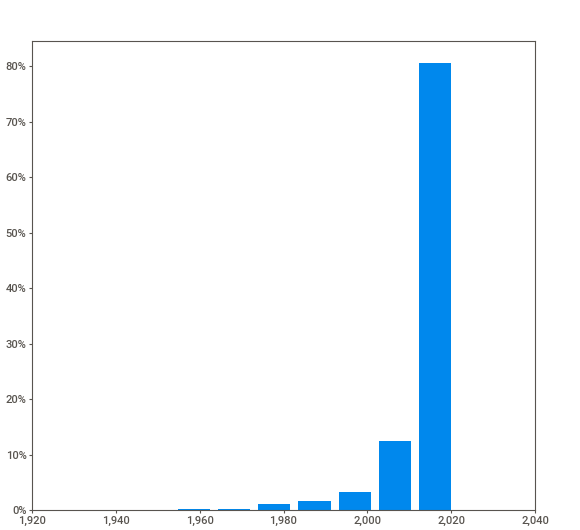
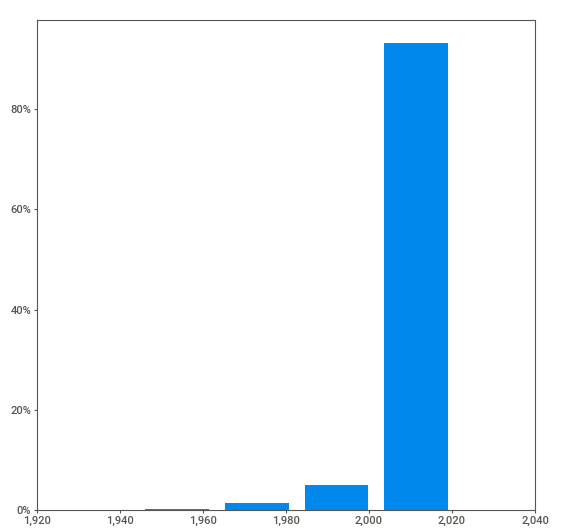
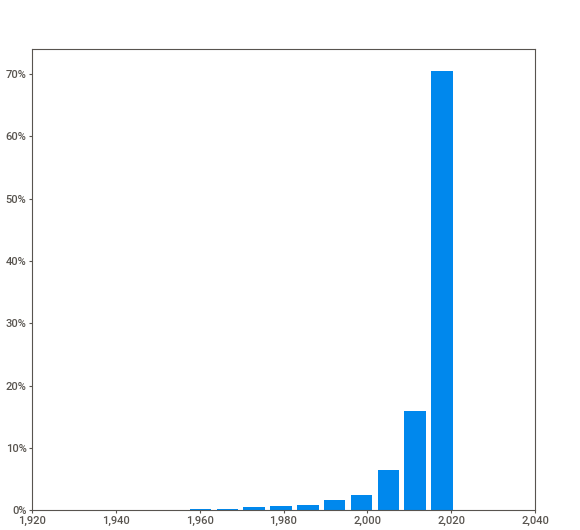
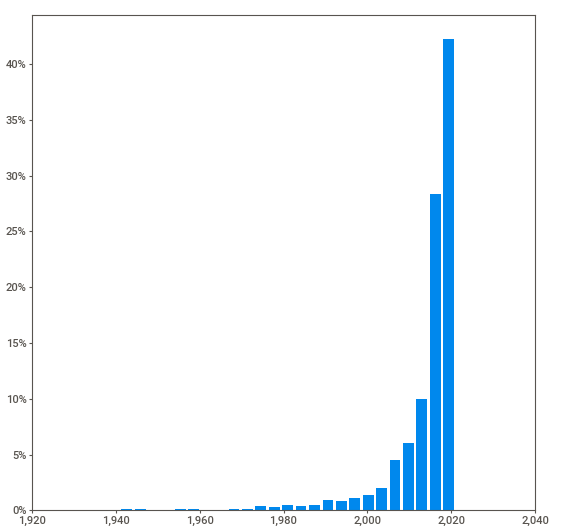
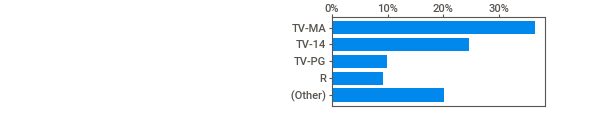
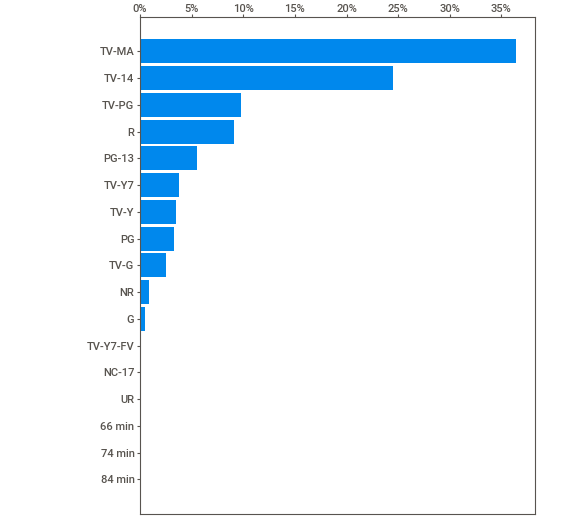
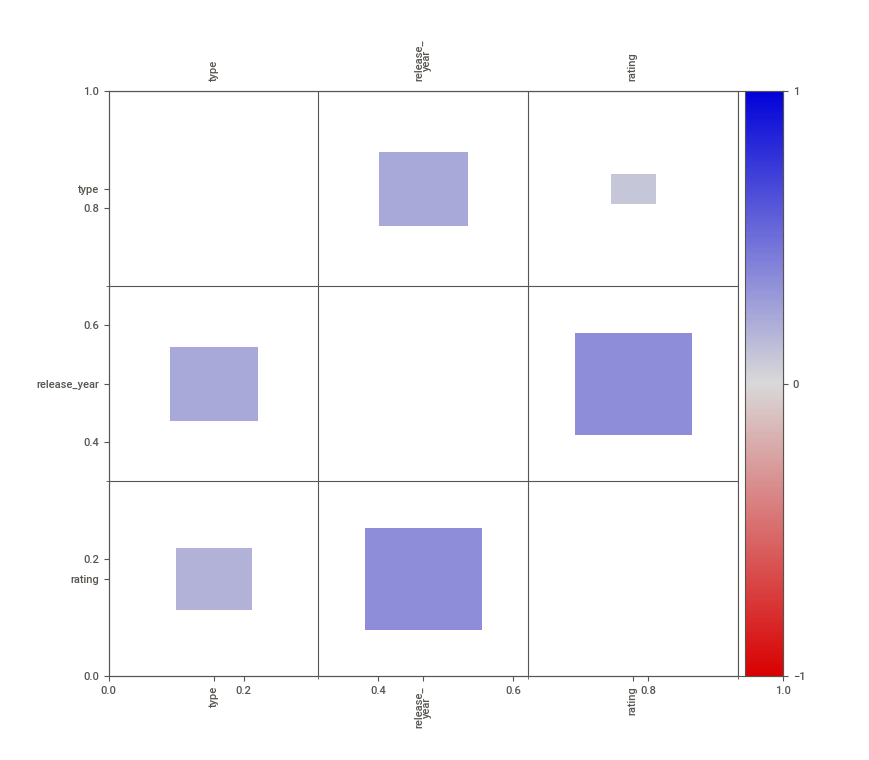
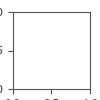

Report 'SWEETVIZ_REPORT.html' was saved to storage.


In [ ]:
report = sv.analyze(df)
report.show_html()
report.show_notebook(filepath = 'SWEETVIZ_REPORT.html')


почти все данные типа string/object, для нормальной работы надо их закодировать

вручную или dataprep library

duration - перевести все в минуты

type - закодировать

rating - что значит и закодировать


3. Decoding

In [ ]:
df_encoded = pd.get_dummies(df['type'], dtype = 'int')

In [ ]:
df_encoded

,Movie,TV Show
0,1,0
1,0,1
2,0,1
3,0,1
4,0,1
...,...,...
8802,1,0
8803,0,1
8804,1,0
8805,1,0


In [ ]:
df_encoded['show_id'] = df['show_id']

In [ ]:
df_encoded.dtypes
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [ ]:
df = df.merge(df_encoded, on = 'show_id', how = 'left')

In [ ]:
df['show_id'].dtype

dtype('O')

In [ ]:
df_encoded['show_id'].dtype

dtype('O')

In [ ]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
       'TV-Y7-FV', 'UR'], dtype=object)

In [ ]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Movie,TV Show
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",1,0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",0,1
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,0,1
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",0,1
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",1,0
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",0,1
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,1,0
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",1,0


cleaning and decoding rating

In [ ]:
mask = df['rating'].str.contains('min', na = False)

df.loc[mask, 'rating'] = np.nan

In [ ]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', nan, 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

In [ ]:
rating_order = [
    'TV-Y', 'TV-G', 'G',
    'TV-Y7', 'TV-Y7-FV',
    'TV-PG', 'PG',
    'TV-14', 'PG-13',
    'TV-MA', 'R',
    'NC-17', 'NR', 'UR'
]

rating_map = {r: i for i, r in enumerate(rating_order)}
df['rating_ord'] = df['rating'].map(rating_map)

In [ ]:
df['rating_ord'].unique()

array([ 8.,  9.,  6.,  7.,  5.,  0.,  3., 10.,  1.,  2., 11., nan, 12.,
        4., 13.])

In [ ]:
df['rating_ord'].dropna()

,rating_ord
0,8.0
1,9.0
2,9.0
3,9.0
4,9.0
...,...
8802,10.0
8803,3.0
8804,10.0
8805,6.0


In [ ]:
df.drop(columns = 'type')

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Movie,TV Show,rating_ord
0,s1,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",1,0,8.0
1,s2,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",0,1,9.0
2,s3,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,0,1,9.0
3,s4,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",0,1,9.0
4,s5,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,0,1,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",1,0,10.0
8803,s8804,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",0,1,3.0
8804,s8805,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,1,0,10.0
8805,s8806,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",1,0,6.0


4. Visualization

In [ ]:
import matplotlib.pyplot as plt

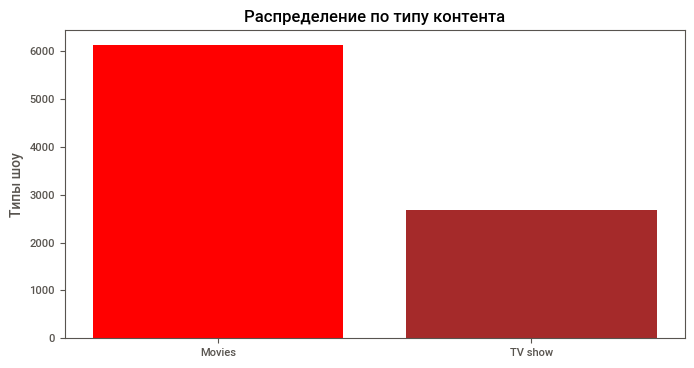

In [ ]:
n_movies = df['Movie'].sum()
n_shows = df ['TV Show'].sum()

labels = ['Movies', 'TV show']
values = [n_movies, n_shows]

plt.figure(figsize = (8,4))
plt.bar(labels, values, color = ['red', 'brown'])
plt.ylabel('Типы шоу')
plt.title('Распределение по типу контента')
plt.show()


В matplotlib можно задавать почти любой цвет, а не только 'gray' и 'black'. Параметр color принимает:

Короткие коды: 'r','g','b','c','m','y','k','w' (red, green, blue, cyan, magenta, yellow, black, white).

Полные именованные цвета: 'steelblue','salmon','gold','darkgreen','orange','purple' и т.д. – их сотни, полный список есть в документации (named colors).

HEX‑коды: '#1f77b4', '#FF5733' и т.п.

Кортежи RGB: (0.2, 0.4, 0.6) – значения от 0 до 1 по каждому каналу.

Для оттенков серого – строка с числом '0.3' … '0.9' (0 – чёрный, 1 – белый).



In [ ]:
df_check = df.loc[:, df.columns != 'show_id']

top 10 directors

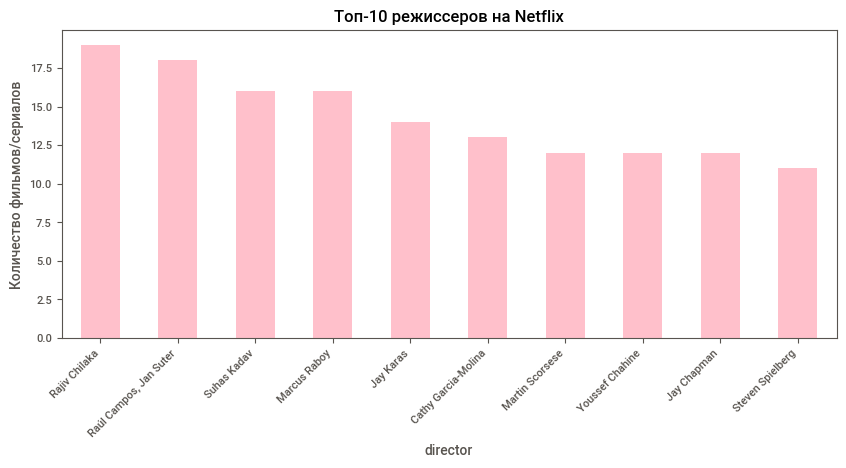

In [ ]:
top_directors = (df['director'].value_counts().head(10))

plt.figure(figsize = (10,4) )
top_directors.plot(kind = 'bar', color = 'pink')
plt.ylabel('Количество фильмов/сериалов')
plt.title('Топ-10 режиссеров на Netflix')
plt.xticks(rotation = 45, ha = 'right' )

plt.show()

country dustriburion

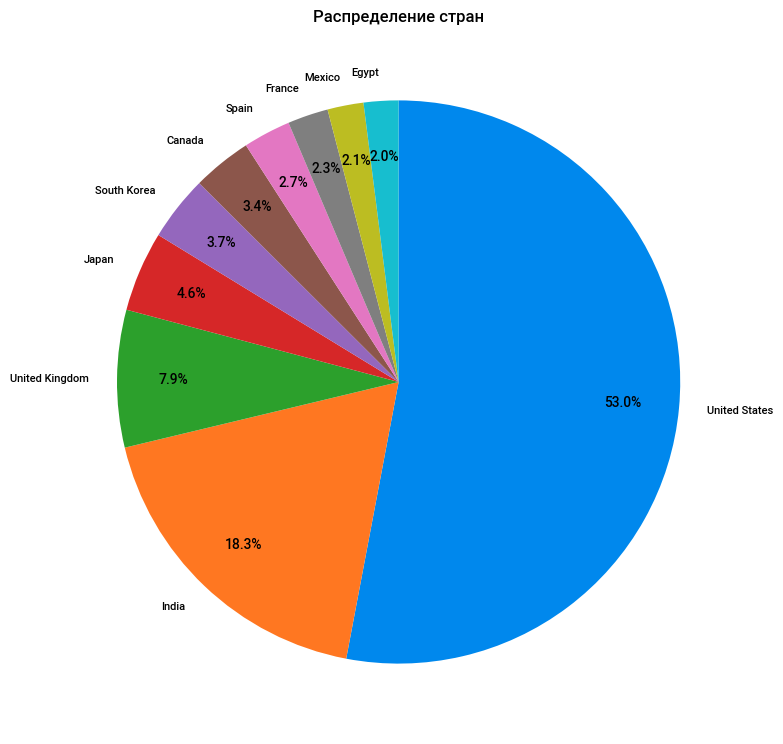

In [ ]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(8, 8))
top_countries.plot(
    kind='pie',
    autopct='%1.1f%%',      # подписи процентов
    startangle=90,          # повернуть, чтобы было красивее
    counterclock=False,     # направление по часовой стрелке
    pctdistance=0.8         # как далеко вынести подписи
)

plt.title('Распределение стран')
plt.ylabel('')              # обычно для pie убирают подпись оси Y
plt.tight_layout()
plt.show()

с каким актером режиссеру лучше всего работать??
в каком жанре чаще всего работает режиссер??
когда чаще всего выпускают фильиы, а когда сериалы (по месяцам/сезонам)??

посмотреть по структуе EDA анализа, разделить вложенные переменные на единичные, проверить все перечисленное выше

4. UNNESTED VARIABLES - UNIVARIATE ANALYSIS

exploding actors

In [ ]:
cast_exploded = (
    df[['show_id', 'cast']]
    .dropna(subset = ['cast'])
    .assign(cast = lambda x: x['cast'].str.split(','))
    .explode('cast')
    )

cast_exploded['cast'] = cast_exploded['cast'].str.strip()
cast_exploded

,show_id,cast
1,s2,Ama Qamata
1,s2,Khosi Ngema
1,s2,Gail Mabalane
1,s2,Thabang Molaba
1,s2,Dillon Windvogel
...,...,...
8806,s8807,Manish Chaudhary
8806,s8807,Meghna Malik
8806,s8807,Malkeet Rauni
8806,s8807,Anita Shabdish


In [ ]:
print('Amount of unique actors:', cast_exploded['cast'].nunique())
print('Actors with highest amount of roles:', cast_exploded['cast'].value_counts().head(10))

Amount of unique actors: 36439
Actors with highest amount of roles: cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Takahiro Sakurai    32
Naseeruddin Shah    32
Rupa Bhimani        31
Om Puri             30
Akshay Kumar        30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64


exploding genre

In [ ]:
genres_exploded = (
    df[['show_id','listed_in']]
      .dropna(subset = ['listed_in'])
      .assign(listed_in = lambda x: x['listed_in'].str.split(','))
      .explode('listed_in')
)

genres_exploded['listed_in'] = genres_exploded['listed_in'].str.strip()
print('Количество уникальных жанров:', genres_exploded['listed_in'].nunique())
print('Список уникальных жанров:',genres_exploded['listed_in'].unique())
print('Топ-10 жанров',genres_exploded['listed_in'].value_counts().head(10))

Количество уникальных жанров: 42
Список уникальных жанров: ['Documentaries' 'International TV Shows' 'TV Dramas' 'TV Mysteries'
 'Crime TV Shows' 'TV Action & Adventure' 'Docuseries' 'Reality TV'
 'Romantic TV Shows' 'TV Comedies' 'TV Horror' 'Children & Family Movies'
 'Dramas' 'Independent Movies' 'International Movies' 'British TV Shows'
 'Comedies' 'Spanish-Language TV Shows' 'Thrillers' 'Romantic Movies'
 'Music & Musicals' 'Horror Movies' 'Sci-Fi & Fantasy' 'TV Thrillers'
 "Kids' TV" 'Action & Adventure' 'TV Sci-Fi & Fantasy' 'Classic Movies'
 'Anime Features' 'Sports Movies' 'Anime Series' 'Korean TV Shows'
 'Science & Nature TV' 'Teen TV Shows' 'Cult Movies' 'TV Shows'
 'Faith & Spirituality' 'LGBTQ Movies' 'Stand-Up Comedy' 'Movies'
 'Stand-Up Comedy & Talk Shows' 'Classic & Cult TV']
Топ-10 жанров listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action

In [ ]:
genres_exploded

,show_id,listed_in
0,s1,Documentaries
1,s2,International TV Shows
1,s2,TV Dramas
1,s2,TV Mysteries
2,s3,Crime TV Shows
...,...,...
8805,s8806,Children & Family Movies
8805,s8806,Comedies
8806,s8807,Dramas
8806,s8807,International Movies


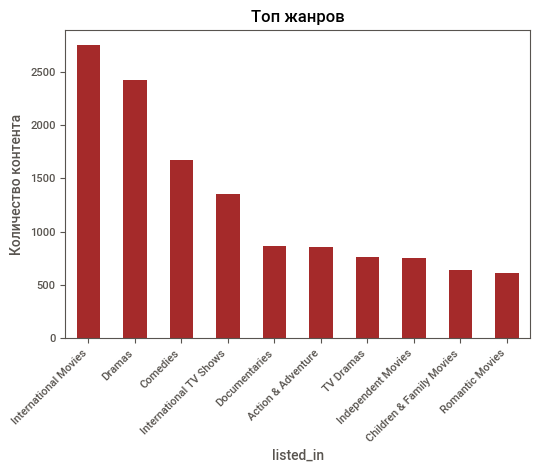

In [ ]:
plt.figure(figsize = (6,4))
genres_exploded.value_counts().head(10).plot(kind = 'bar', color = 'brown')
plt.ylabel('Количество контента')
plt.title('Топ жанров')
plt.xticks(rotation = 45, ha = 'right')

plt.show()

5. Bivariate analysis

genre for top actors

In [ ]:
genres_actors = pd.merge(cast_exploded, genres_exploded, on = 'show_id', how='right')
genres_actors

,show_id,cast,listed_in
0,s1,NaN,Documentaries
1,s2,Ama Qamata,International TV Shows
2,s2,Khosi Ngema,International TV Shows
3,s2,Gail Mabalane,International TV Shows
4,s2,Thabang Molaba,International TV Shows
...,...,...,...
149507,s8807,Manish Chaudhary,Music & Musicals
149508,s8807,Meghna Malik,Music & Musicals
149509,s8807,Malkeet Rauni,Music & Musicals
149510,s8807,Anita Shabdish,Music & Musicals


In [ ]:
top10_actors = cast_exploded['cast'].value_counts().head(10).index

actor_genres_top10 = (
    genres_actors[genres_actors['cast'].isin(top10_actors)]
    .groupby('cast')['listed_in']
    .apply(lambda x: sorted(set(x)))
    .reset_index(name = 'genres')
)

for _, row in actor_genres_top10.iterrows():
    actor = row['cast']
    genres = ', '.join(row['genres'])   # или '\n  - '.join(...) для списка
    print(f'{actor}: {genres}\n')

#actor_genres_top10_fmt = actor_genres_top10.copy()
#actor_genres_top10_fmt['genres'] = actor_genres_top10_fmt['genres'].apply(format_genres)

#print(actor_genres_top10_fmt.to_string(index=False))
#pd.set_option('display.max_colwidth', None)
#pd.set_option('display.max_rows', 200)
#pd.set_option('display.max_seq_items', None)
#print(actor_genres_top10)

Akshay Kumar: Action & Adventure, Children & Family Movies, Comedies, Dramas, International Movies, Music & Musicals, Romantic Movies, Sports Movies, Thrillers

Amitabh Bachchan: Action & Adventure, Classic Movies, Comedies, Cult Movies, Dramas, International Movies, Music & Musicals, Romantic Movies, Thrillers

Anupam Kher: Action & Adventure, Children & Family Movies, Classic Movies, Comedies, Crime TV Shows, Dramas, Independent Movies, International Movies, International TV Shows, Music & Musicals, Romantic Movies, Sci-Fi & Fantasy, TV Comedies, Thrillers

Julie Tejwani: Children & Family Movies, Kids' TV, Movies, Sports Movies

Naseeruddin Shah: Action & Adventure, Children & Family Movies, Comedies, Documentaries, Dramas, Independent Movies, International Movies, Music & Musicals, Romantic Movies, Sci-Fi & Fantasy, Thrillers

Om Puri: Action & Adventure, Children & Family Movies, Comedies, Cult Movies, Dramas, Faith & Spirituality, Independent Movies, International Movies, Music &

top genre for every top actor

In [ ]:
top_genre_per_actor = (
    genres_actors
    .groupby('cast')['listed_in']
    .agg(lambda s:s.value_counts().idxmax()) # агрегация всех значений по жанру в один список(берем максимальные значения)
    .reset_index(name='top_genre')
)

top_genre_per_actor10 = (
    genres_actors[genres_actors['cast'].isin(top10_actors)]
    .groupby('cast')['listed_in']
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index(name = 'top_genre')
)

top_genre_per_actor10

,cast,top_genre
0,Akshay Kumar,International Movies
1,Amitabh Bachchan,International Movies
2,Anupam Kher,International Movies
3,Julie Tejwani,Children & Family Movies
4,Naseeruddin Shah,Dramas
5,Om Puri,International Movies
6,Rupa Bhimani,Children & Family Movies
7,Shah Rukh Khan,International Movies
8,Takahiro Sakurai,Anime Series
9,Yuki Kaji,Anime Series


genres for top director



In [ ]:
df_dir = df.dropna(subset = ['director','listed_in']).copy()
df_dir['director'] = df_dir['director'].astype('string').str.strip()
df_dir['listed_in'] = df_dir['listed_in'].astype('string')

director_genre = (
    df_dir[['director','listed_in']]
    .assign(listed_in = lambda x: x ['listed_in'].str.split(','))
    .explode('listed_in')

)

director_genre['listed_in'] = director_genre['listed_in'].str.strip()
director_genre

,director,listed_in
0,Kirsten Johnson,Documentaries
2,Julien Leclercq,Crime TV Shows
2,Julien Leclercq,International TV Shows
2,Julien Leclercq,TV Action & Adventure
5,Mike Flanagan,TV Dramas
...,...,...
8805,Peter Hewitt,Children & Family Movies
8805,Peter Hewitt,Comedies
8806,Mozez Singh,Dramas
8806,Mozez Singh,International Movies


In [ ]:
top10_directors_genres = director_genre['director'].value_counts().head(10).index

directors10_genres =(
    director_genre[director_genre['director'].isin(top10_directors_genres)]
    .groupby('director')['listed_in']
    .apply(lambda x : sorted(set(x)))
    .reset_index(name = 'genres')
)

directors10_genres

,director,genres
0,Cathy Garcia-Molina,"[Comedies, Dramas, International Movies, Romantic Movies]"
1,David Dhawan,"[Action & Adventure, Comedies, Dramas, International Movies, Music & Musicals, Romantic Movies, Sci-Fi & Fantasy]"
2,Kunle Afolayan,"[Comedies, Dramas, Horror Movies, International Movies, Romantic Movies, Thrillers]"
3,Mae Czarina Cruz,"[Children & Family Movies, Comedies, Dramas, International Movies, Romantic Movies]"
4,Martin Scorsese,"[Children & Family Movies, Classic Movies, Comedies, Documentaries, Dramas, Independent Movies, Music & Musicals, Sports Movies, Thrillers]"
5,Steven Spielberg,"[Action & Adventure, Children & Family Movies, Classic Movies, Dramas, Sci-Fi & Fantasy]"
6,Suhas Kadav,"[Children & Family Movies, Comedies, Music & Musicals]"
7,Toshiya Shinohara,"[Action & Adventure, Anime Features, International Movies]"
8,Youssef Chahine,"[Action & Adventure, Classic Movies, Dramas, Independent Movies, International Movies, Romantic Movies]"
9,Yılmaz Erdoğan,"[Action & Adventure, Comedies, Dramas, International Movies, Romantic Movies]"


top genre for top director

In [ ]:
top10_directors = top_directors.index

top_genre_per_director10 = (
    director_genre
   .loc[lambda df_:df_['director'].isin(top10_directors)]
   .groupby('director')['listed_in']
   .agg(lambda x: x.value_counts().idxmax())
   .reset_index(name = 'top_genre')
)

top_genre_per_director10

,director,top_genre
0,Cathy Garcia-Molina,International Movies
1,Jay Chapman,Stand-Up Comedy
2,Jay Karas,Stand-Up Comedy
3,Marcus Raboy,Stand-Up Comedy
4,Martin Scorsese,Dramas
5,Rajiv Chilaka,Children & Family Movies
6,"Raúl Campos, Jan Suter",Stand-Up Comedy
7,Steven Spielberg,Dramas
8,Suhas Kadav,Children & Family Movies
9,Youssef Chahine,Dramas


top directors and actors working together

In [ ]:
# 0. Нормализуем колонку director
df['director'] = df['director'].replace('nan', pd.NA)
df = df.dropna(subset=['director'])
df['director'] = df['director'].astype(str).str.strip()

# 1. Топ-10 режиссёров
top10_directors = df['director'].value_counts().head(10).index.tolist()

result = []

for director_name in top10_directors:
    # 2. Все тайтлы этого режиссёра
    df_dir = df[df['director'] == director_name].copy()

    if df_dir.empty:
        print('Пусто для режиссёра:', repr(director_name))
        continue

    cast_exploded = (
        df_dir['cast']
          .dropna()
          .str.split(',')
          .explode()
          .str.strip()
    )

    if cast_exploded.empty:
        print('Нет актёров для:', repr(director_name))
        continue

    top_actors_for_dir = cast_exploded.value_counts()
    most_common_actor = top_actors_for_dir.idxmax()
    count = top_actors_for_dir.max()

    result.append({
        'director': director_name,
        'actor': most_common_actor,
        'count': count
    })

top_pairs = pd.DataFrame(result)
top_pairs

/tmp/ipykernel_11663/3041394475.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['director'] = df['director'].astype(str).str.strip()


,director,actor,count
0,Rajiv Chilaka,Julie Tejwani,17
1,"Raúl Campos, Jan Suter",Sofía Niño de Rivera,3
2,Suhas Kadav,Saurav Chakraborty,8
3,Marcus Raboy,Vir Das,2
4,Jay Karas,Bill Burr,3
5,Cathy Garcia-Molina,Joross Gamboa,6
6,Martin Scorsese,Robert De Niro,4
7,Youssef Chahine,Mahmoud El Meleigy,4
8,Jay Chapman,D.L. Hughley,2
9,Steven Spielberg,Harrison Ford,4
